# Fine-tuning for label prediction in single-cell resolution spatial transcriptomics data

Here, we demonstrate how to fine-tune the pretraimed model and perform label prediction using human [CosMx lung data](https://brukerspatialbiology.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/nsclc-ffpe-dataset/). This dataset contains three replicates of lung tissue samples with annotated cell type and niche labels.

In [1]:
from huggingface_hub import snapshot_download
import scanpy as sc
import torch
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from spaGFM.stRoamer.utils.data_build import initial_pyG_graph
from spaGFM.stRoamer.training.run_train_ft import run_ft
from spaGFM.stRoamer.inference.run_inference import graph_from_h5ad
from spaGFM.stRoamer.inference.run_inference_ft import run_inference_ft

/fs/ess/PAS1475/yzhong/sf_project/random_test/spaGFM_dev/08_27_26/spaGFM_1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-01 16:15:00,583 - datasets - INFO - PyTorch version 2.10.0+cu126 available.
2026-09-01 16:15:00,588 - datasets - INFO - JAX version 0.4.38 available.


Here, we download our pretrained model from [Hugging Face](https://huggingface.co/tinywind123/spaGFM). This collection come with models with different sizes. The processed demo CosMx lung data in h5ad format is available under the `demo_data` directory. The pretrained models are stored in the `spaGFM` directory. The `local_dir` specifies the directory where the collection will be downloaded.

In [2]:
# 1. Download the pretrained model
model_path = snapshot_download(
    repo_id="tinywind123/spaGFM",
    local_dir="spaGFM_model"
)

2026-09-01 16:15:06,182 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/tinywind123/spaGFM/revision/main "HTTP/1.1 200 OK"
Fetching 13 files: 100%|██████████| 13/13 [00:00<00:00, 384.83it/s]


First, we need to build cellular graphs for each sample and initialize node features using gene expression profiles.
If spatial coordinates are saved in `adata.obsm['spatial']`, `coord_x` and `coord_y` can be ignored.

In [3]:
# 2. Initialize graph using AnnData object
data_paths = sorted(glob.glob(os.path.join(model_path, 'demo_data/*.h5ad')))
lung5_adata_dict = {os.path.basename(path): sc.read_h5ad(path) for path in data_paths}
for key, adata in lung5_adata_dict.items():
    print(f"Initializing graph for {key}...")
    lung5_adata_dict[key]=initial_pyG_graph(
        adata,
        model_dir=os.path.join(model_path, 'scFM/scGPT_human'),
        gene_col='index',               # Column name of gene names in adata.var
        batch_size=256,                 # Batch size for node embedding initialization
        coord_x='raw_sdimx',            # Column name of x coordinates in adata.obs
        coord_y='raw_sdimy',            # Column name of y coordinates in adata.obs
    )

Initializing graph for cosmx_human_lung_Lung5_Rep1.h5ad...
scGPT - INFO - match 958/960 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 383/383 [00:33<00:00, 11.35it/s]
/fs/ess/PAS1475/yzhong/sf_project/random_test/spaGFM_dev/08_27_26/spaGFM/scFM/scGPT/scgpt/tasks/cell_emb.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


Initializing graph for cosmx_human_lung_Lung5_Rep2.h5ad...
scGPT - INFO - match 958/960 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 414/414 [00:41<00:00, 10.04it/s]
/fs/ess/PAS1475/yzhong/sf_project/random_test/spaGFM_dev/08_27_26/spaGFM/scFM/scGPT/scgpt/tasks/cell_emb.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


Initializing graph for cosmx_human_lung_Lung5_Rep3.h5ad...
scGPT - INFO - match 958/960 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 383/383 [00:31<00:00, 12.29it/s]
/fs/ess/PAS1475/yzhong/sf_project/random_test/spaGFM_dev/08_27_26/spaGFM/scFM/scGPT/scgpt/tasks/cell_emb.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


Here, we need to prepare the datasets by converting adata into pyG graphs. Here, we used Lung5_rep1 as training dataset, Lung5_rep2 as validation dataset and Lung5_rep3 as testing dataset. The objective is to predict niche labels for cells in Lung5_rep3 using the model trained on Lung5_rep1, evaluated on Lung5_rep2. We exemplify the node label we used here as `niche`, which is stored in `adata.obs['niche']`.

In [4]:
# 3. Prepare the data for fine-tuning
label_col = 'niche'
adatas = {
    'train': lung5_adata_dict['cosmx_human_lung_Lung5_Rep1.h5ad'],
    'val': lung5_adata_dict['cosmx_human_lung_Lung5_Rep2.h5ad'],
    'test': lung5_adata_dict['cosmx_human_lung_Lung5_Rep3.h5ad'],
}

missing_label_splits = [split for split, adata in adatas.items() if label_col not in adata.obs]
if missing_label_splits:
    raise KeyError(f"Missing adata.obs['{label_col}'] for splits: {missing_label_splits}")

label_categories = sorted(
    set().union(*(adata.obs[label_col].astype(str).unique() for adata in adatas.values()))
)
label_to_code = {label: idx for idx, label in enumerate(label_categories)}
label_mapping = {idx: label for label, idx in label_to_code.items()}

pyg_graphs = {}
for split, adata in adatas.items():
    graph = graph_from_h5ad(adata)
    labels = adata.obs[label_col].astype(str).map(label_to_code)
    if labels.isna().any():
        missing = sorted(adata.obs.loc[labels.isna(), label_col].astype(str).unique())
        raise ValueError(f'{split} has labels missing from label mapping: {missing}')
    graph.niche = torch.tensor(labels.astype('int64').to_numpy(), dtype=torch.long)
    graph.y = graph.niche
    graph.label_mapping = label_mapping
    pyg_graphs[split] = graph

train_adata_pyg_graph = pyg_graphs['train']
val_adata_pyg_graph = pyg_graphs['val']
test_adata_pyg_graph = pyg_graphs['test']

print("Train graph:", train_adata_pyg_graph)
print("Validation graph:", val_adata_pyg_graph)
print("Test graph:", test_adata_pyg_graph)

Train graph: Data(
  x=[98002, 512],
  edge_index=[2, 577056],
  x_key='X_scGPT',
  niche=[98002],
  y=[98002],
  label_mapping={
    0='immune',
    1='lymphoid structure',
    2='macrophages',
    3='myeloid-enriched stroma',
    4='neutrophils',
    5='plasmablast-enriched stroma',
    6='stroma',
    7='tumor interior',
    8='tumor-stroma boundary',
  }
)
Validation graph: Data(
  x=[105800, 512],
  edge_index=[2, 623500],
  x_key='X_scGPT',
  niche=[105800],
  y=[105800],
  label_mapping={
    0='immune',
    1='lymphoid structure',
    2='macrophages',
    3='myeloid-enriched stroma',
    4='neutrophils',
    5='plasmablast-enriched stroma',
    6='stroma',
    7='tumor interior',
    8='tumor-stroma boundary',
  }
)
Test graph: Data(
  x=[97809, 512],
  edge_index=[2, 576278],
  x_key='X_scGPT',
  niche=[97809],
  y=[97809],
  label_mapping={
    0='immune',
    1='lymphoid structure',
    2='macrophages',
    3='myeloid-enriched stroma',
    4='neutrophils',
    5='plasmablast

In this setting, we add a classification head on top of the pre-trained model for the task of node-level prediction. Here, we used spaGFM-36M as the backbone model for fine-tuning. You can also try spaGFM-317M to see if it improves the performance.

In [5]:
# 4. Set the parameters for fine-tuning
device = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
ft_params = {}
ft_params['walk_length']=8
ft_params['mode'] = 'train'
ft_params['task_type'] = 'classification'
ft_params['save_path'] = 'spaGFM_model_ft'
ft_params['subgraph_cls_token'] = False
ft_params['subgraph_pooling'] = 'attn'
ft_params['output_dim'] = len(label_mapping)
ft_params['linear_decoder'] = True
ft_params['frozen_backbone'] = False
ft_params['ft_batch_size'] = 250
ft_params['epochs'] = 5
ft_params['save_epoch_wise_size'] = 5
ft_params['lr'] = 0.001
ft_params['device'] = device
ft_params["log_every_n_batches"] = None
ft_params['use_amp'] = True
model_file=os.path.join(model_path, 'spaGFM/human_36M.pt')

run_ft(model_file=model_file, 
       train_graph=train_adata_pyg_graph, 
       val_graph=val_adata_pyg_graph,
       ft_params=ft_params)

2026-09-01 16:17:14,459 - spaGFM.stRoamer.models.stRoamer_ft - INFO - Loading model parameters from /fs/ess/PAS1475/yzhong/sf_project/random_test/spaGFM_dev/08_27_26/spaGFM_model/spaGFM/human_36M.pt
/fs/ess/PAS1475/yzhong/sf_project/random_test/spaGFM_dev/08_27_26/spaGFM/spaGFM/stRoamer/models/encoder.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(
2026-09-01 16:17:15,302 - spaGFM.stRoamer.training.run_train_ft - INFO - Mixed precision fine-tuning enabled with dtype: bfloat16
2026-09-01 16:18:24,878 - spaGFM.stRoamer.training.run_train_ft - INFO - Epoch 1 done. Avg Loss: 0.41299020955884125, Val F1 Macro: 0.5076253414154053
2026-09-01 16:18:24,880 - spaGFM.stRoamer.training.run_train_ft - INFO - New best model with F1 Macro: 0.5076253414154053. Saving to spaGFM_model_ft/best_model.pt
2026-09-01 16:19:34,852 - spaGFM.stRoamer.training.run_train_ft - INFO - Epoch

Here, we use fine-tuned model to predict niche labels for Lung5_rep3 using the model trained on Lung5_rep1, evaluated on Lung5_rep2.
`test_attn_weights` is the contribution score of each random walk to the node prediction. `test_logits` is the predicted logits for each cell in Lung5_rep3.

In [6]:
# 5. Run inference on the test set
model_file='spaGFM_model_ft/best_model.pt'
test_attn_weights, test_logits = run_inference_ft(test_adata_pyg_graph, 
                                                  model_file, 
                                                  device,
                                                  use_amp=True)
print("Test attention weights shape:", test_attn_weights.shape)
print("Test logits shape:", test_logits.shape)

2026-09-01 16:23:05,634 - spaGFM.stRoamer.models.stRoamer_ft - INFO - Loading model parameters from spaGFM_model_ft/best_model.pt
2026-09-01 16:23:06,892 - spaGFM.stRoamer.inference.inference_ft - INFO - Using the following device during inference: cuda:0


Test attention weights shape: torch.Size([97809, 128, 1])
Test logits shape: torch.Size([97809, 9])


Here, we visualize the predictive performance of the fine-tuned model on Lung5_rep3, stratified by the original niche labels.

macro F1 from per-niche F1: 0.5280
weighted F1 by niche support: 0.7608
overall accuracy: 0.7517


,niche,n_cells,predicted_as_niche,true_positive,precision,recall,f1
2,macrophages,3,41,0,0.000000,0.000000,0.000000
0,immune,323,146,22,0.150685,0.068111,0.093817
4,neutrophils,961,3353,591,0.176260,0.614984,0.273992
5,plasmablast-enriched stroma,8269,10524,4986,0.473774,0.602975,0.530623
8,tumor-stroma boundary,8457,9436,5300,0.561679,0.626700,0.592410
7,tumor interior,13751,11557,10479,0.906723,0.762054,0.828118
3,myeloid-enriched stroma,20378,20400,17706,0.867941,0.868878,0.868409
1,lymphoid structure,22147,22099,18736,0.847821,0.845984,0.846901
6,stroma,23520,20253,15707,0.775539,0.667815,0.717657


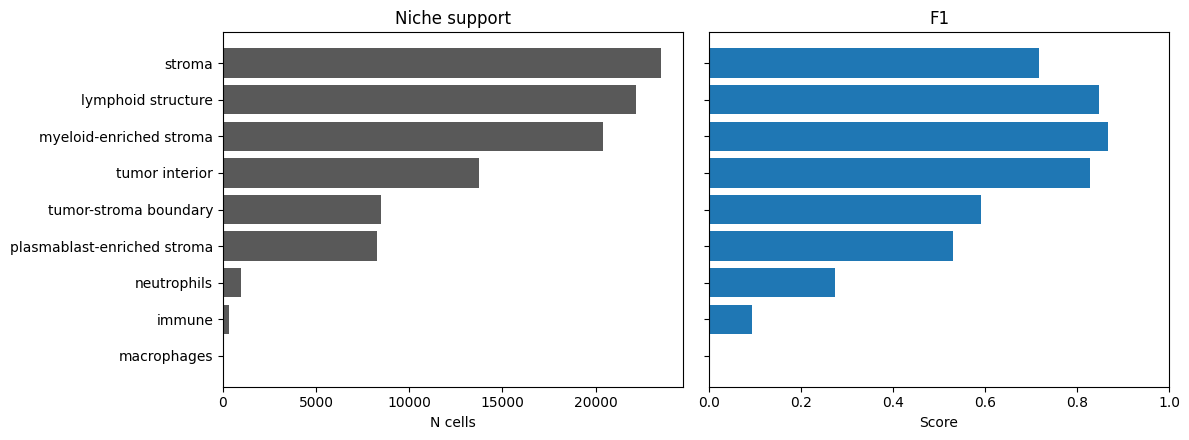

In [7]:
# 6. Evaluate the predictions
true_codes = test_adata_pyg_graph.y.detach().cpu().numpy()
pred_codes = test_logits.detach().cpu().argmax(dim=1).numpy()
class_ids = np.array(sorted(label_mapping.keys()))
niche_names = [label_mapping[int(i)] for i in class_ids]

support = np.bincount(true_codes, minlength=len(class_ids))[class_ids]
predicted = np.bincount(pred_codes, minlength=len(class_ids))[class_ids]
tp = np.bincount(true_codes[pred_codes == true_codes], minlength=len(class_ids))[class_ids]

precision = np.divide(tp, predicted, out=np.zeros_like(tp, dtype=float), where=predicted > 0)
recall = np.divide(tp, support, out=np.zeros_like(tp, dtype=float), where=support > 0)
f1_per_niche = np.divide(
    2 * precision * recall,
    precision + recall,
    out=np.zeros_like(precision, dtype=float),
    where=(precision + recall) > 0,
)

niche_eval_df = pd.DataFrame({
    'niche': niche_names,
    'n_cells': support,
    'predicted_as_niche': predicted,
    'true_positive': tp,
    'precision': precision,
    'recall': recall,
    'f1': f1_per_niche,
}).sort_values('n_cells')

macro_f1_from_classes = float(np.mean(f1_per_niche))
weighted_f1_from_classes = float(np.average(f1_per_niche, weights=support))
overall_accuracy = float(np.mean(pred_codes == true_codes))

print(f'macro F1 from per-niche F1: {macro_f1_from_classes:.4f}')
print(f'weighted F1 by niche support: {weighted_f1_from_classes:.4f}')
print(f'overall accuracy: {overall_accuracy:.4f}')
display(niche_eval_df)

# Store predictions for downstream spatial/error analysis.
adatas['test'].obs['pred_niche'] = pd.Categorical(
    [label_mapping[int(i)] for i in pred_codes],
    categories=niche_names,
)
adatas['test'].obs['correct_niche_pred'] = pred_codes == true_codes

plot_df = niche_eval_df.sort_values('n_cells', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].barh(plot_df['niche'], plot_df['n_cells'], color='0.35')
axes[0].set_xlabel('N cells')
axes[0].set_title('Niche support')

axes[1].barh(plot_df['niche'], plot_df['f1'], color='tab:blue')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Score')
axes[1].set_title('F1')
plt.tight_layout()
plt.show()
